<a href="https://colab.research.google.com/github/AsmaGhamacha/AsmaGhamacha/blob/main/4_Experiments_Batch_Normalization_vs_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment: Batch Normalization vs Dropout Regularization.


In the following experiment we will study the impact of <b>batch normalization and dropout on ConvNet to reduce the loss (error)</b>

###setup:

- We will define a model where we have a choice to insert batch norm or dropout after a convolutional layer.
- We will train each variant model on the **Cifar100 dataset**.
- Visualize the differences in validation loss between results of model with dropout, with batch normalization, and with nothing.

- Then , repeat the same steps  by changing the locations of dropout and batch norm layers between convolutions (before, after activation functions & after maxpool).

<b>Tips:</b>  We first place Batch Normalization & Dropout operations before activations, then after activations, and finally after max pooling layers.


## Hypothesis:

<b> Validation loss (Generalization error) will achieve the lowest values when batch normalization is inserted between convolutional layers.</b>, let's see if that's correct practically!



###Cifar100 dataset:
This dataset has 100 classes containing 600 images each. There are 500 training images and 100 testing images per class.


## Experiment Setup


### Base Convolutional Layer
These same successive conv layers will be always used in all built models below, they called "conv block"

<img src="https://github.com/harrisonjansma/Research-Computer-Vision/blob/master/08-12-18%20Batch%20Norm%20vs%20Dropout/images/convblock.png?raw=1" height = 250>

Each model is based on the same architecure consisting of 5 convolutional blocks, and it concludes with a single fully connected layer, containing 100 units and softmax activation.

### Architecture Variants
Within each convolutional block we will place either a dropout layer, batch normalization, or nothing (control) at the same place within the convolutional block.


For example, in the first section we place a Batch norm and dropout operation before activation functions. This makes each of the above Conv2D(3x3, ReLU) layers take this architecture :

<img src="https://github.com/harrisonjansma/Research-Computer-Vision/blob/master/08-12-18%20Batch%20Norm%20vs%20Dropout/images/Variants.png?raw=1">

### Dropout Impact
To test the effect of dropout, we will build same three models with different dropout rates: either 0.5, 0.3, or 0.1.

### Conclusion
<b>To conclude, in each section we will train and test a control network, a batch-normalized network, and three dropout networks (with rates of 0.5, 0.3, or 0.1), </b> and compare between their results of accuracy and loss.
Please plot every result and comment your comparison




### Imports

In [ ]:
import tensorflow as tf
import numpy as np
import os

import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import img_to_array,array_to_img,load_img
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from keras.models import Model, Sequential
from keras.layers import Input

from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import BatchNormalization
from keras.layers import GlobalAveragePooling2D
from keras.layers import Activation
from keras.layers import Conv2D, MaxPooling2D, Dense
from keras.layers import MaxPooling2D, Dropout, Flatten

import time

In [ ]:
!pip install np_utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56439 sha256=89d083dec7b9dfc4e585931760ca5e90a2062b947b15323137c46f85bdcc9073
  Stored in directory: /root/.cache/pip/wheels/b6/c7/50/2307607f44366dd021209f660045f8d51cb976514d30be7cc7
Successfully built np_utils


### Data Loading and Preprocessing.

In [ ]:
from keras.datasets import cifar100
from keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

#scale and regularize the dataset inputs
x_train = (x_train-np.mean(x_train))
x_test = (x_test - x_test.mean())

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

#onehot encode the target classes
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


train_datagen = ImageDataGenerator()
train_generator = train_datagen.flow(x_train,
                                     y = y_train,
                                    batch_size=80,
                                    shuffle=True,
                                    )


In [ ]:
y_train.shape

# Dropout and Batch Norm before Activations

### Model Construction

In [ ]:
def input_conv_block(model, bn=False, dropout=False, rate=0.4, activation="relu"):
    """
    The first convolutional block in each architecture. Seperated so we can
    specify the input shape.
    """
    model.add(Conv2D(60,3, padding = "same", input_shape = x_train.shape[1:]))
    if bn:
        model.add(BatchNormalization())
    if dropout:
        model.add(Dropout(rate))
    model.add(Activation(activation))

    model.add(Conv2D(60,3, padding = "same"))
    if bn:
        model.add(BatchNormalization())
    if dropout:
        model.add(Dropout(rate))
    model.add(Activation(activation))

    model.add(MaxPooling2D())
    return model

def conv_block(model, bn=False, dropout=False, rate=0.5, activation = "relu"):
    """
    Generic convolutional block with 2 stacked 3x3 convolutions, max pooling, dropout,
    and an optional Batch Normalization.
    """
    model.add(Conv2D(60,3, padding = "same"))
    if bn:
        model.add(BatchNormalization())
    if dropout:
        model.add(Dropout(rate))
    model.add(Activation(activation))

    model.add(Conv2D(60,3, padding = "same"))
    if bn:
        model.add(BatchNormalization())
    if dropout:
        model.add(Dropout(rate))
    model.add(Activation(activation))
    model.add(MaxPooling2D())
    return model

def conv_block_final(model, bn=False, dropout=False, rate=0.5, activation = "relu"):
    """
    I bumped up the number of filters in the final block. I made this seperate so that
    I might be able to integrate Global Average Pooling later on.
    """
    model.add(Conv2D(100,3, padding = "same"))
    if bn:
        model.add(BatchNormalization())
    if dropout:
        model.add(Dropout(rate))
    model.add(Activation(activation))

    model.add(Conv2D(100,3, padding = "same"))
    if bn:
        model.add(BatchNormalization())
    if dropout:
        model.add(Dropout(rate))
    model.add(Activation(activation))

    model.add(Flatten())
    return model

def fn_block(model):
    """
    build a very deep fully connected block.
    """
    model.add(Dense(1000, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(100, activation = "softmax"))
    return model

def build_model(blocks=3, bn=False, dropout=False, rate=0.5, activation = "relu"):
    """
    Builds a sequential network based on the specified parameters.

    blocks: number of convolutional blocks in the network, must be greater than 2.
    bn: whether to include batch normalization or not.
    activation: activation function to use throughout the network.
    """
    model = Sequential()

    model = input_conv_block(model, bn=bn, dropout=dropout, rate=rate, activation=activation)

    for block in range(1,blocks-1):
        model = conv_block(model, bn=bn, dropout=dropout, rate=rate, activation = activation)

    model = conv_block_final(model, bn=bn, dropout=dropout, rate=rate, activation=activation)
    model = fn_block(model)

    return model

def compile_model(model, optimizer = "rmsprop", loss = "categorical_crossentropy", metrics = ["accuracy"]):
    """
    Compiles a neural network.

    model: the network to be compiled.
    optimizer: the optimizer to use.
    loss: the loss to use.
    metrics: a list of keras metrics.
    """
    model.compile(optimizer = optimizer,
                 loss = loss,
                 metrics = metrics)
    return model

### Compile Models

Now, Build the entire model, making 5 versions:

- control object: to build an architecture of 5 blocks without dropout, without BN
- batchNorm: to build an architecture of 5 blocks without dropout, with BN operation
- dropout5: to build an architecture of 5 blocks with a dropout of rate =0.5, without BN operation

- dropout3: to build an architecture of 5 blocks with a dropout of rate =0.3, without BN operation

- dropout1: to build an architecture of 5 blocks with a dropout of rate =0.1, without BN operation

Each time you build a new model object you need to compile it


In [ ]:
control = build_model(blocks = 5, bn=False, dropout=False, activation = "relu")
control = compile_model(control)

batchNorm = build_model(blocks = 5, bn=True, dropout=False, activation = "relu")
batchNorm = compile_model(batchNorm)

dropout5 =  build_model(blocks = 5, bn=False, dropout=True,rate = 0.5, activation = "relu")
dropout5 = compile_model(dropout5)

dropout3 = build_model(blocks = 5, bn=False, dropout=True,rate = 0.3, activation = "relu")
dropout3 = compile_model(dropout3)

dropout1 = build_model(blocks = 5, bn=False, dropout=True, rate=0.1, activation = "relu")
dropout1 = compile_model(dropout1)

## Train the Models

In [ ]:
def trainModel(model, savedest):
    start = time.time()
    #savedest is the path of saved model that you decide to save the model on
    model_checkpoint = ModelCheckpoint(savedest,save_best_only = True)  # this confis will save the model when it gets the best performance

    history = model.fit(
        train_generator,
        steps_per_epoch=625,
        epochs=10,
        verbose=1,
        validation_data = (x_test, y_test),
        callbacks = [model_checkpoint])

    end = time.time()

    print("Training time: ", (end - start)/60, " minutes")
    return history

def plotModel(history, modelname):
    plt.figure(figsize=(12,6))
    # summarize history for accuracy
    plt.subplot(121)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(modelname+' Accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    # summarize history for loss
    plt.subplot(122)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(modelname+' Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.show()
    return None

def plotAllModels(history1, history2, history3, history4, history5, title):
    plt.figure(figsize=(12,6))
    # summarize history for accuracy
    plt.subplot(121)
    plt.plot(history1.history['val_accuracy'])
    plt.plot(history2.history['val_accuracy'])
    plt.plot(history3.history['val_accuracy'])
    plt.plot(history4.history['val_accuracy'])
    plt.plot(history5.history['val_accuracy'])
    plt.title(title + ' Accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['Control', 'Batch Norm', 'Dropout (0.5)', 'Dropout (0.3)', 'Dropout (0.1)'], loc='upper left')
    # summarize history for loss
    plt.subplot(122)
    plt.plot(history1.history['val_loss'])
    plt.plot(history2.history['val_loss'])
    plt.plot(history3.history['val_loss'])
    plt.plot(history4.history['val_loss'])
    plt.plot(history5.history['val_loss'])

    plt.title(title+ ' Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['Control', 'Batch Norm', 'Dropout', 'Dropout (0.3)', 'Dropout (0.1)'], loc='upper right')
    plt.show()
    return None

### Control Model
No dropout no batch norm.

In [ ]:
history1 = trainModel(control, 'models/control.h5')

Epoch 1/10
625/625 [==============================] - 19s 19ms/step - loss: 4.2530 - accuracy: 0.0429 - val_loss: 3.8740 - val_accuracy: 0.0897


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/10
625/625 [==============================] - 11s 17ms/step - loss: 3.7490 - accuracy: 0.1105 - val_loss: 3.5078 - val_accuracy: 0.1574
Epoch 3/10
625/625 [==============================] - 10s 16ms/step - loss: 3.4339 - accuracy: 0.1684 - val_loss: 3.2524 - val_accuracy: 0.2104
Epoch 4/10
625/625 [==============================] - 10s 15ms/step - loss: 3.2275 - accuracy: 0.2079 - val_loss: 3.2254 - val_accuracy: 0.2094
Epoch 5/10
625/625 [==============================] - 11s 17ms/step - loss: 3.0785 - accuracy: 0.2374 - val_loss: 3.0085 - val_accuracy: 0.2473
Epoch 6/10
625/625 [==============================] - 11s 17ms/step - loss: 2.9512 - accuracy: 0.2637 - val_loss: 2.9695 - val_accuracy: 0.2606
Epoch 7/10
625/625 [==============================] - 10s 16ms/step - loss: 2.8654 - accuracy: 0.2807 - val_loss: 2.9149 - val_accuracy: 0.2759
Epoch 8/10
625/625 [==============================] - 10s 16ms/step - loss: 2.8082 - accuracy: 0.2942 - val_loss: 2.8946 - val_accuracy:

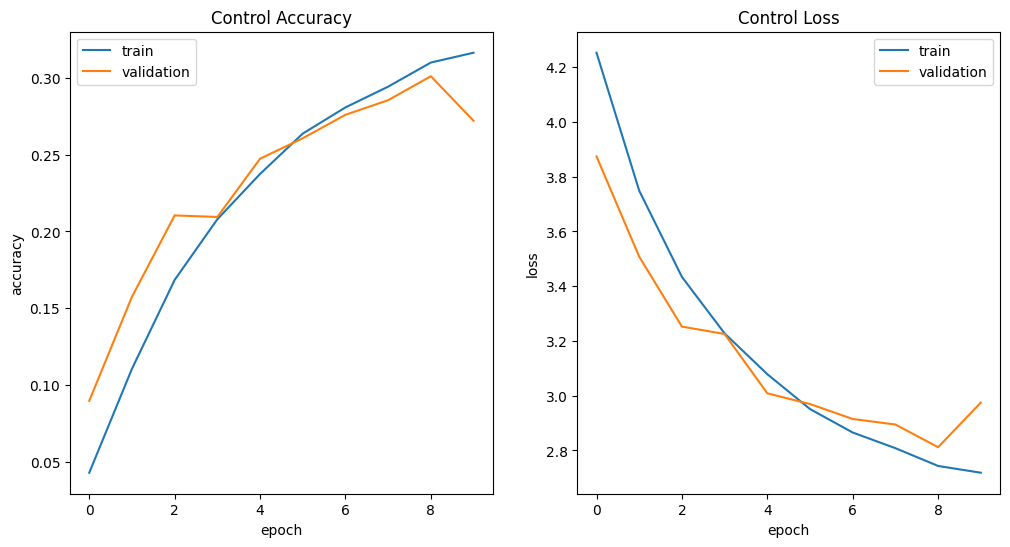

In [ ]:
plotModel(history1, "Control")

##Interpretation
We can see that with the Control Model (without Batch Normalization and Dropout) the result is pretty of moderate performance .

### Batch Normalization
Batch norm after convolutions and prior to activations.

In [ ]:
history2 = trainModel(batchNorm, 'models/batchNorm.h5')

Epoch 1/10
625/625 [==============================] - 19s 22ms/step - loss: 3.7936 - accuracy: 0.1090 - val_loss: 3.3069 - val_accuracy: 0.1919
Epoch 2/10
625/625 [==============================] - 13s 20ms/step - loss: 3.0070 - accuracy: 0.2366 - val_loss: 2.9829 - val_accuracy: 0.2618
Epoch 3/10
625/625 [==============================] - 13s 20ms/step - loss: 2.6226 - accuracy: 0.3130 - val_loss: 2.6847 - val_accuracy: 0.3105
Epoch 4/10
625/625 [==============================] - 12s 20ms/step - loss: 2.3599 - accuracy: 0.3693 - val_loss: 2.7623 - val_accuracy: 0.3097
Epoch 5/10
625/625 [==============================] - 13s 20ms/step - loss: 2.1676 - accuracy: 0.4140 - val_loss: 2.3533 - val_accuracy: 0.3792
Epoch 6/10
625/625 [==============================] - 13s 20ms/step - loss: 2.0048 - accuracy: 0.4508 - val_loss: 2.2161 - val_accuracy: 0.4097
Epoch 7/10
625/625 [==============================] - 13s 20ms/step - loss: 1.8734 - accuracy: 0.4857 - val_loss: 2.3404 - val_accuracy:

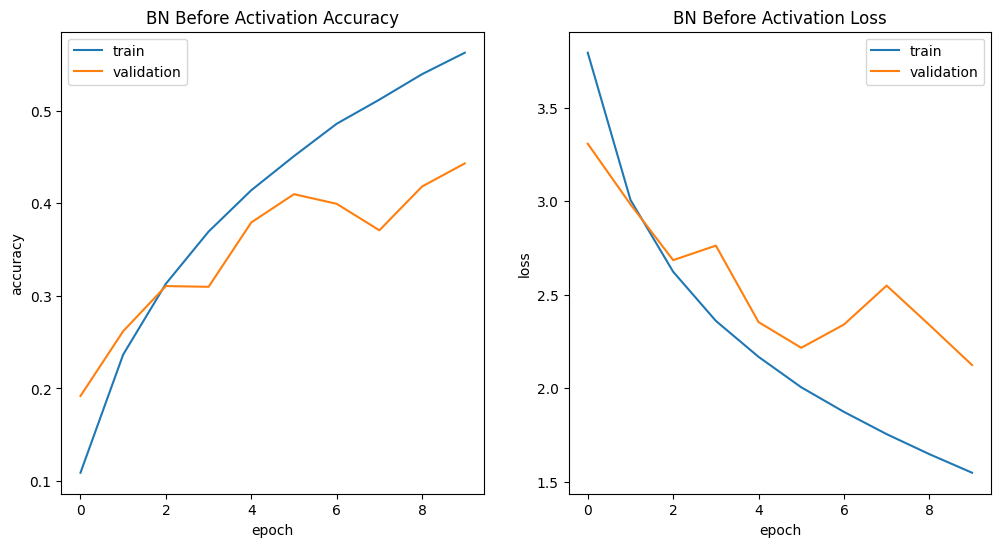

In [ ]:
plotModel(history2, "BN Before Activation")

### Dropout 0.5
Dropout prior to activation with rate 0.5

In [ ]:
history3 = trainModel(?, 'models/Dropout5.h5')

In [ ]:
plotModel(?, "D (0.5) Before Activation")

### Dropout 0.3
Dropout prior to activation with rate 0.3

In [ ]:
history4 = trainModel(?, 'models/Dropout3.h5')

In [ ]:
plotModel(?, "D (0.3) Before Activation")

### Dropout 0.1
Dropout prior to activation with rate 0.1

In [ ]:
history5 = trainModel(?, 'models/Dropout1.h5')

In [ ]:
plotModel(history5, "D (0.1) Before Activation")

### Performance of BN and Dropout before activations
Plot  the performance (accuracies and losses) of all 5 models plotted together.

In [ ]:
plotAllModels(history1, history2, history3, history4, history5, "All Models before activations")

##What is your conclusion from the first build ?


# Let's try Dropout and Batch norm after activations

## Model Construction

Rebuild the same blocks, changing the order of BN and Dropout operations to be after activation function

In [ ]:
def input_conv_block(model, bn=False, dropout=False, rate=0.4, activation="relu"):


    return model

def conv_block(model, bn=False, dropout=False, rate=0.5, activation = "relu"):


    return model

def conv_block_final(model, bn=False, dropout=False, rate=0.5, activation = "relu"):



    return model

def fn_block(model):

    model.add(Dense(1000, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(100, activation = "softmax"))

    return model

def build_model(blocks=3, bn=False, dropout=False, rate=0.5, activation = "relu"):

    model = Sequential()

    model = input_conv_block(model, bn=bn, dropout=dropout, rate=rate, activation=activation)

    for block in range(1,blocks-1):
        model = conv_block(model, bn=bn, dropout=dropout, rate=rate, activation = activation)

    model = conv_block_final(model, bn=bn, dropout=dropout, rate=rate, activation=activation)
    model = fn_block(model)

    return model

def compile_model(model, optimizer = "rmsprop", loss = "categorical_crossentropy", metrics = ["accuracy"]):

    model.compile(optimizer = optimizer,
                 loss = loss,
                 metrics = metrics)
    return model

### Compile the Models

In [ ]:
control = build_model(?)
control = compile_model(control)

batchNorm = build_model(?)
batchNorm = compile_model(batchNorm)

dropout5 = build_model(?)
dropout5 = compile_model(dropout5)

dropout3 = build_model(?)
dropout3 = compile_model(dropout3)

dropout1 = build_model(?)
dropout1 = compile_model(dropout1)

## Training the Models

### Control

In [ ]:
history6 = trainModel(control, 'models/control.h5')

In [ ]:
plotModel(history6, "Control")

### Batch Norm

In [ ]:
history7 = trainModel(?, 'models/batchNorm.h5')

In [ ]:
plotModel(history7, "BN After Activation")

### Dropout 0.5

In [ ]:
history8 = trainModel(?, 'models/Dropout5.h5')

In [ ]:
plotModel(history8, "D (0.5) After Activation")

### Dropout 0.3

In [ ]:
history9 = trainModel(?, 'models/Dropout3.h5')

In [ ]:
plotModel(history9, "D (0.3) After Activation")

### Dropout 0.1

In [ ]:
history10 = trainModel(?, 'models/Dropout1.h5')

In [ ]:
plotModel(history10, "D (0.1) After Activation")

### Performance of BN and Dropout after activations
Plot the performances (accuracies and loss ) of all models together

In [ ]:
plotAllModels(history6, history7, history8, history9, history10, "All Models after activations")

# Let's try to add BN and Dropout after maxpooling?
Rebuild the same blocks, changing the order of BN and Dropout operations to be after Maxpooling
## Model Construction

In [ ]:
def input_conv_block(model, bn=False, dropout=False, rate=0.4, activation="relu"):



    return model

def conv_block(model, bn=False, dropout=False, rate=0.5, activation = "relu"):



    return model

def conv_block_final(model, bn=False, dropout=False, rate=0.5, activation = "relu"):



    return model

def fn_block(model):



    return model

def build_model(blocks=3, bn=False, dropout=False, rate=0.5, activation = "relu"):

    model = Sequential()

    model = input_conv_block(model, bn=bn, dropout=dropout, rate=rate, activation=activation)

    for block in range(1,blocks-1):
        model = conv_block(model, bn=bn, dropout=dropout, rate=rate, activation = activation)

    model = conv_block_final(model, bn=bn, dropout=dropout, rate=rate, activation=activation)
    model = fn_block(model)

    return model

def compile_model(model, optimizer = "rmsprop", loss = "categorical_crossentropy", metrics = ["accuracy"]):

    model.compile(optimizer = optimizer,
                 loss = loss,
                 metrics = metrics)
    return model


### Compile the models.

In [ ]:
control = build_model(?)
control = compile_model(control)

batchNorm = build_model(?)
batchNorm = compile_model(batchNorm)

dropout5 = build_model(?)
dropout5 = compile_model(dropout5)

dropout3 = build_model(?)
dropout3 = compile_model(dropout3)

dropout1 = build_model(?)
dropout1 = compile_model(dropout1)

## Train the models.

### Control Model

In [ ]:
history11 = trainModel(?, 'models/control.h5')

In [ ]:
plotModel(history11, "Control")

### Batch Norm

In [ ]:
history12 = trainModel(?, 'models/batchNorm.h5')

In [ ]:
plotModel(?, "After MaxPool")

### Dropout 0.5

In [ ]:
history13 = trainModel(?, 'models/Dropout5.h5')

In [ ]:
plotModel(history13, "D (0.5) After MaxPool")

### Dropout 0.3

In [ ]:
history14 = trainModel(?, 'models/Dropout3.h5')

In [ ]:
plotModel(history14, "D (0.3) After MaxPool")

### Dropout 0.1

In [ ]:
history15 = trainModel(?, 'models/Dropout1.h5')

In [ ]:
plotModel(history15, "D (0.1) After MaxPool")

### Performance of BN and Dropout after maxpooling

In [ ]:
plotAllModels(history11, history12, history13, history14, history15, "All Models after MaxPooling")

**Exercise**
* Comment every graph by what you state, comparing results
* Have a global view about the three figures of five curves, which performance indicates to the best configuration (BatchNorm, Dropouts) before, after activation functions or after maxpool layer ?
* In a general case, with the batch norm regularization, can dropout be eliminated ?
* For a time reason, we trained only 10 epochs, with only a limited set of hyperparameters, now feel free to do your experimental game. Starting from the architecture you find the optimial, modify, add, tune to and then train, to minimise the loss and get a higher accuracy, and share me your experience, and what you concluded

Please, Use your own notebook to implement and organize your work, then pleas email me the following elements:

 * share me your notebook to my address mymehio@gmail.com
  * deadline: 22/02 11:59 PM (don't touch after this time)

